In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from imblearn.over_sampling import SMOTE

In [ ]:
# Load Dataset
df = pd.read_csv('/content/bank_churn_data.csv')
df.head()

,user_id,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,...,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10127 non-null  int64  
 1   attrition_flag            10127 non-null  object 
 2   customer_age              10127 non-null  int64  
 3   gender                    10127 non-null  object 
 4   dependent_count           10127 non-null  int64  
 5   education_level           10127 non-null  object 
 6   marital_status            10127 non-null  object 
 7   income_category           10127 non-null  object 
 8   card_category             10127 non-null  object 
 9   months_on_book            10127 non-null  int64  
 10  total_relationship_count  10127 non-null  int64  
 11  months_inactive_12_mon    10127 non-null  int64  
 12  contacts_count_12_mon     10127 non-null  int64  
 13  credit_limit              10127 non-null  float64
 14  total_

In [ ]:
df.describe()

,user_id,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [ ]:
df.isna().sum()

,0
user_id,0
attrition_flag,0
customer_age,0
gender,0
dependent_count,0
education_level,0
marital_status,0
income_category,0
card_category,0
months_on_book,0


Tidak terdapat missing value pada data

In [ ]:
df.duplicated().sum()

np.int64(0)

Tidak terdapat data duplikat

#### Churn Distribution

In [ ]:
# Cek variabel target
count = df['attrition_flag'].value_counts()
percentage = df["attrition_flag"].value_counts(normalize=True) * 100

pd.DataFrame({
    "Count": count,
    "Percentage (%)": percentage.round(2)
})

,Count,Percentage (%)
attrition_flag,,
Existing Customer,8500,83.93
Attrited Customer,1627,16.07


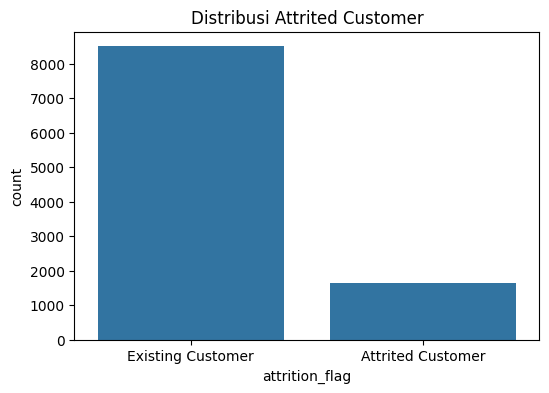

In [ ]:
# Cek distribusi variabel Target
plt.figure(figsize=(6,4))
sns.countplot(x='attrition_flag',data=df)
plt.title('Distribusi Attrited Customer')
plt.show()

Berdasarkan distribusi churn terlihat bahwa sebagian besar pelanggan (84%) masih merupakan Existing Customer, sementara sebagian kecil lainnya (16%) merupakan Attrited Customer (churn) yang telah berhenti menggunakan layanan banknya.
Ini menunjukkan adanya ketidakseimbangan kelas yang mana perlu untuk diperhatikan pada tahap pemodelan nantinya.

## Exploratory Data Analysis

Analisis Churn Berdasarkan Variabel Kategorik

In [ ]:
# Churn berdasarkan variabel kategorikal

def churn_by_category(cols):
  tabel = pd.crosstab(df[cols],df['attrition_flag'],normalize='index') * 100
  tabel = tabel.round(2)
  print(tabel)

  tabel.plot(kind='bar',stacked=True, figsize=(6,4))
  plt.title(f'Churn Rate by {cols}')
  plt.show()

attrition_flag  Attrited Customer  Existing Customer
gender                                              
F                           17.36              82.64
M                           14.62              85.38


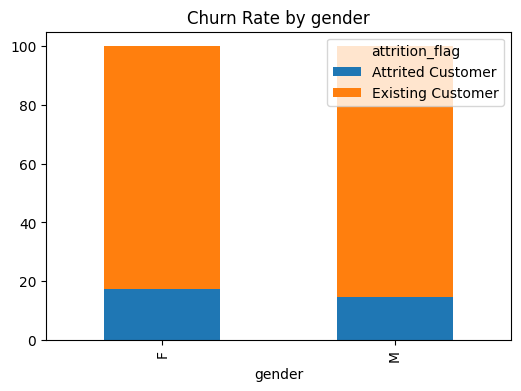

In [ ]:
churn_by_category('gender')

Distribusi Attrition (churn) antara laki laki dan perempuan relatif mirip, sehingga gender kemungkinan bukan menjadi faktor utama yang mempengaruhi churn.

attrition_flag   Attrited Customer  Existing Customer
education_level                                      
College                      15.20              84.80
Doctorate                    21.06              78.94
Graduate                     15.57              84.43
High School                  15.20              84.80
Post-Graduate                17.83              82.17
Uneducated                   15.94              84.06
Unknown                      16.85              83.15


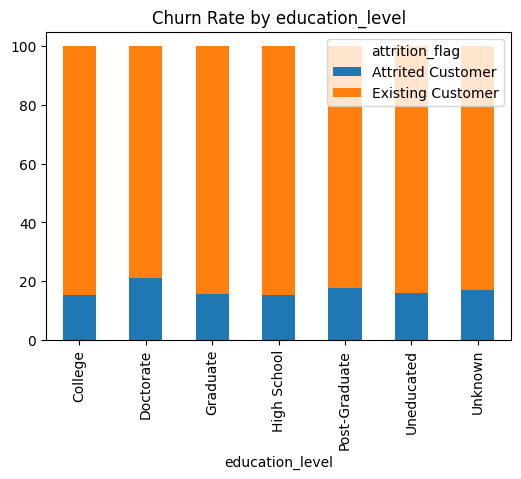

In [ ]:
churn_by_category('education_level')

attrition_flag  Attrited Customer  Existing Customer
marital_status                                      
Divorced                    16.18              83.82
Married                     15.13              84.87
Single                      16.94              83.06
Unknown                     17.22              82.78


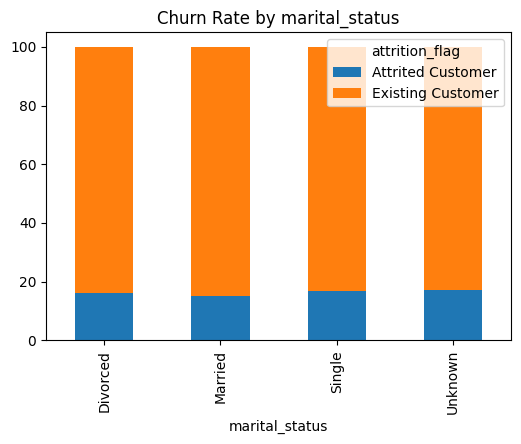

In [ ]:
churn_by_category('marital_status')

Distribusi Attrition (churn) antar status perkawinan relatif mirip, sehingga marital status kemungkinan bukan menjadi faktor utama yang mempengaruhi churn.

attrition_flag   Attrited Customer  Existing Customer
income_category                                      
$120K +                      17.33              82.67
$40K - $60K                  15.14              84.86
$60K - $80K                  13.48              86.52
$80K - $120K                 15.77              84.23
Less than $40K               17.19              82.81
Unknown                      16.82              83.18


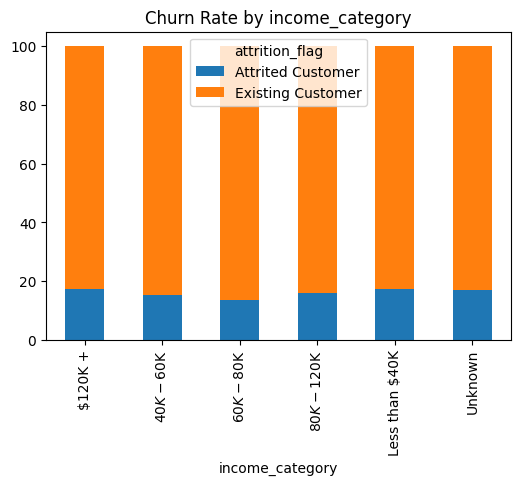

In [ ]:
churn_by_category('income_category')

Tingkat churn pada setiap kategori pendapatan relatif mirip dengan rentang sekitar 13% hingga 17%. Hal ini menunjukkan bahwa income category tidak menjadi faktor utama yang mempengaruhi churn pelanggan secara signifikan.

attrition_flag  Attrited Customer  Existing Customer
card_category                                       
Blue                        16.10              83.90
Gold                        18.10              81.90
Platinum                    25.00              75.00
Silver                      14.77              85.23


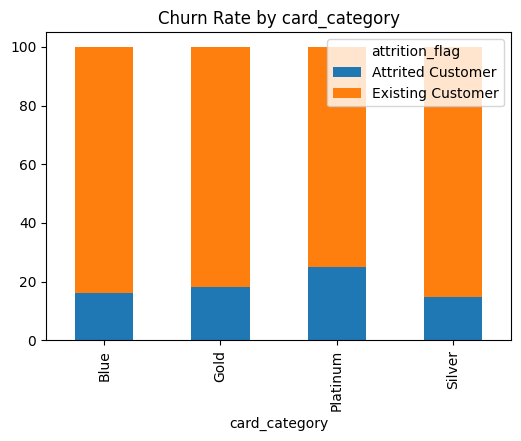

In [ ]:
churn_by_category('card_category')

In [ ]:
df['card_category'].value_counts()

,count
card_category,
Blue,9436
Silver,555
Gold,116
Platinum,20


Berdasarkan jenis kartu, terlihat bahwa pelanggan dengan kartu Platinum memiliki tingkat churn tertinggi sekitar 25%. Namun, kategori ini memiliki jumlah pelanggan yang lebih sedikit sehingga persentase churn dapat terlihat lebih tinggi. Untuk kategori kartu yang lebih umum seperti Blue, Silver, dan Gold, tingkat churn relatif mirip dengan kisaran sekitar 14% hingga 18%. Hal ini menunjukkan bahwa jenis kartu kemungkinan bukan faktor utama yang mempengaruhi churn pelanggan.

Analisis Churn Berdasarkan Variabel Numerik

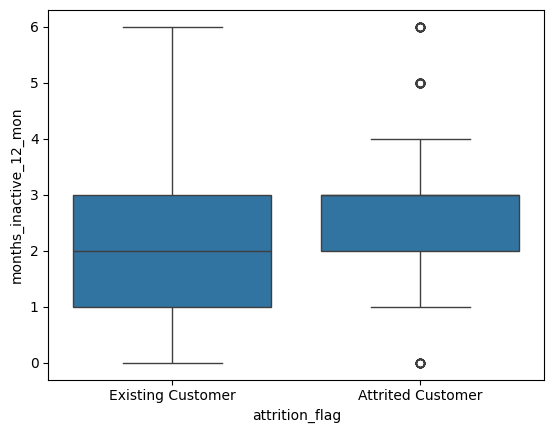

In [ ]:
# Month Inactive vs Attrition
sns.boxplot(x='attrition_flag', y='months_inactive_12_mon', data=df)
plt.show()

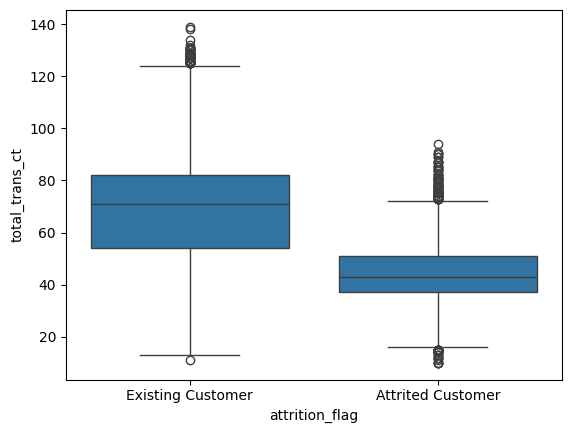

In [ ]:
# Total Transaction Count vs Attrition
sns.boxplot(x='attrition_flag', y='total_trans_ct', data=df)
plt.show()

Terlihat bahwa pelanggan dengan jumlah transaksi yang rendah lebih cendrung untuk churn. Ini menunjukkan bahwa minimnya transaksi dapat menjadi indikator churnnya pelanggan.

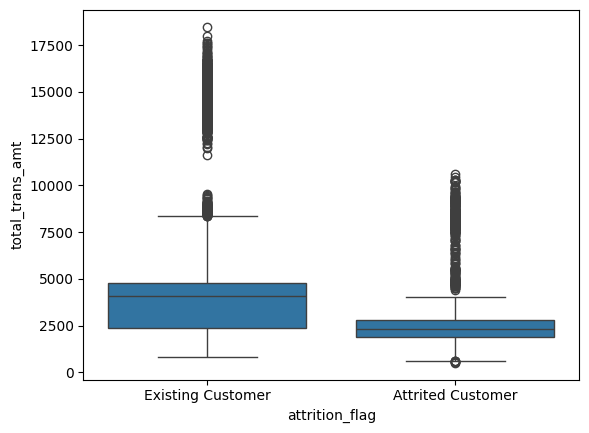

In [ ]:
# Total Transaction Amount vs Attrition
sns.boxplot(x='attrition_flag', y='total_trans_amt', data=df)
plt.show()

Pelanggan dengan total transaksi rendah lebih cendrung churn. Ini menunjukkan bahwa minimnya nilai transaksi dapat menjadi indikator churnnya pelanggan.

In [ ]:
# Grouping months_on_book (tenure)
df['tenure_group'] = pd.cut(df['months_on_book'],
                            bins=[0,24,36,48,60],
                            labels=['<2yr','2-3yr','3-4yr','>4yr'])

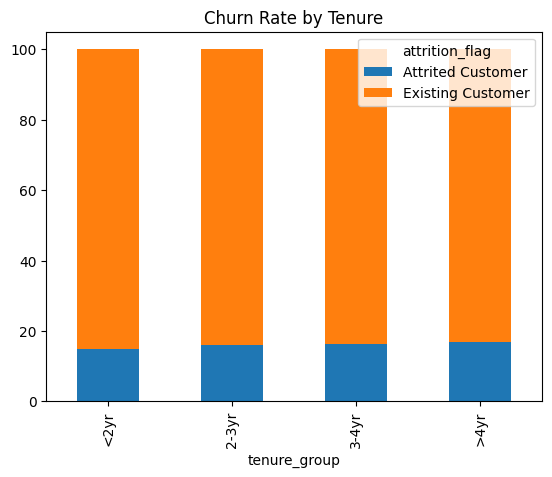

In [ ]:
tenure_churn = pd.crosstab(df['tenure_group'], df['attrition_flag'], normalize='index')*100

tenure_churn.plot(kind='bar',stacked=True)
plt.title("Churn Rate by Tenure")
plt.show()

Berdasarkan lama hubungan pelanggan menggunakan bank terlihat bahwa tingkat attrition (churn) relatif mirip diberbagai kelompok tenure. Ini mengindikasikan bahwa lamanya seseorang menjadi nasabah bukan merupakan faktor utama yang mempengaruhi churn.

In [ ]:
df['trans_ct_group'] = pd.qcut(df['total_trans_ct'], q=4)

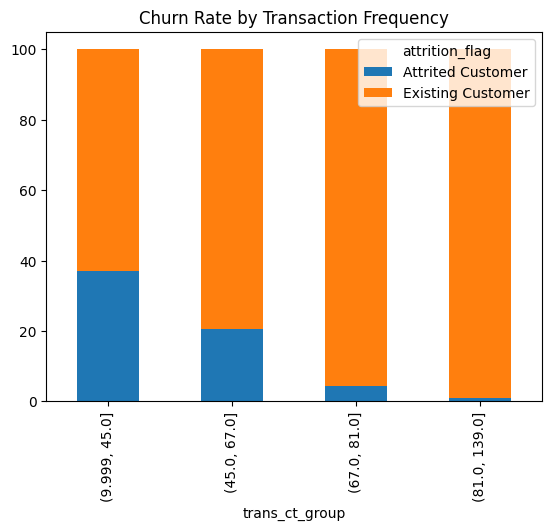

In [ ]:
trans_churn = pd.crosstab(df['trans_ct_group'], df['attrition_flag'], normalize='index')*100

trans_churn.plot(kind='bar',stacked=True)
plt.title("Churn Rate by Transaction Frequency")
plt.show()

Berdasarkan Transaction Behavior terlihat bahwa frekuensi transaksi yang rendah (10-45) dalam setahun memiliki tingkat attrition (churn) yang cukup tinggi dibanding grup frekuensi transaksi lainnya.
Hal ini menunjukkan bahwa aktivitas transaksi merupakan salah satu indikator penting dari loyalitas pelanggan.

## Feature Engineering

In [ ]:
# Encoding variabel target

df['attrition_flag'] = df['attrition_flag'].map({
    'Attrited Customer': 1,
    'Existing Customer': 0
})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   user_id                   10127 non-null  int64   
 1   attrition_flag            10127 non-null  int64   
 2   customer_age              10127 non-null  int64   
 3   gender                    10127 non-null  object  
 4   dependent_count           10127 non-null  int64   
 5   education_level           10127 non-null  object  
 6   marital_status            10127 non-null  object  
 7   income_category           10127 non-null  object  
 8   card_category             10127 non-null  object  
 9   months_on_book            10127 non-null  int64   
 10  total_relationship_count  10127 non-null  int64   
 11  months_inactive_12_mon    10127 non-null  int64   
 12  contacts_count_12_mon     10127 non-null  int64   
 13  credit_limit              10127 non-null  floa

In [ ]:
# Hapus kolom redundan yang hanya digunakan untuk EDA
df = df.drop(columns=['tenure_group','trans_ct_group'])

In [ ]:
# Encoding fitur kategorik
df_model = pd.get_dummies(df, drop_first=True)

In [ ]:
# Split dataset
X = df_model.drop(['attrition_flag'], axis=1)
y = df_model['attrition_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42, stratify=y
)

In [ ]:
# Scaling fitur
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Handling imbalanced data
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

## Modeling

Baseline model (Logistic Regression)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train_scaled, y_train)

baseline_pred = baseline_model.predict(X_test_scaled)

print("Baseline Model: Logistic Regression")
print(classification_report(y_test, baseline_pred))

Baseline Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      1701
           1       0.79      0.56      0.65       325

    accuracy                           0.91      2026
   macro avg       0.85      0.77      0.80      2026
weighted avg       0.90      0.91      0.90      2026



Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Model")
print(classification_report(y_test, rf_pred))

Random Forest Model
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1701
           1       0.95      0.76      0.84       325

    accuracy                           0.95      2026
   macro avg       0.95      0.87      0.91      2026
weighted avg       0.95      0.95      0.95      2026



XGBoost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Model")
print(classification_report(y_test, xgb_pred))

XGBoost Model
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1701
           1       0.95      0.86      0.90       325

    accuracy                           0.97      2026
   macro avg       0.96      0.92      0.94      2026
weighted avg       0.97      0.97      0.97      2026



Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score

Logistic Regression

In [ ]:
logreg_cv = cross_val_score(
    baseline_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='recall'
)

print("Logistic Regression CV Recall:", logreg_cv.mean())

Logistic Regression CV Recall: 0.57991452991453


Random Forest

In [ ]:
rf_cv = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

print("Random Forest CV Recall:", rf_cv.mean())

Random Forest CV Recall: 0.7741880341880342


XGBoost

In [ ]:
xgb_cv = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

print("XGBoost CV Recall:", xgb_cv.mean())

XGBoost CV Recall: 0.8924668435013263


Perbandingan Model

In [ ]:
print("Average Recall Score Cross Validation")

print("Logistic Regression:", logreg_cv.mean())
print("Random Forest:", rf_cv.mean())
print("XGBoost:", xgb_cv.mean())

Average Recall Score Cross Validation
Logistic Regression: 0.57991452991453
Random Forest: 0.7741880341880342
XGBoost: 0.8924668435013263


Berdasarkan hasil cross validation menggunakan metrik recall, model XGBoost menunjukkan performa terbaik dengan nilai recall sebesar 0.89, diikuti oleh Random Forest sebesar 0.77 dan Logistic Regression sebesar 0.58. Hal ini menunjukkan bahwa model ensemble seperti Random Forest dan XGBoost mampu menangkap pola yang lebih kompleks dibandingkan model linear sederhana seperti Logistic Regression. Dalam konteks churn prediction, recall yang tinggi sangat penting karena memungkinkan perusahaan untuk mengidentifikasi sebagian besar pelanggan yang berpotensi churn sehingga dapat dilakukan strategi retensi lebih awal.

## Model Evaluation

Best Model : XGBoost

In [ ]:
y_pred = xgb_model.predict(X_test)

print("Classification Report - XGBoost")
print(classification_report(y_test, y_pred))

Classification Report - XGBoost
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1701
           1       0.95      0.86      0.90       325

    accuracy                           0.97      2026
   macro avg       0.96      0.92      0.94      2026
weighted avg       0.97      0.97      0.97      2026



* Precision 0.95 berarti sekitar 95% pelanggan yang diprediksi churn oleh model benar-benar churn.

* Recall 0.86 menunjukkan bahwa model mampu mendeteksi sekitar 86% pelanggan yang benar-benar churn.

* F1-score 0.90 menunjukkan bahwa model memiliki keseimbangan yang baik antara kemampuan mendeteksi churn dan ketepatan prediksinya.

Confusion Matrix

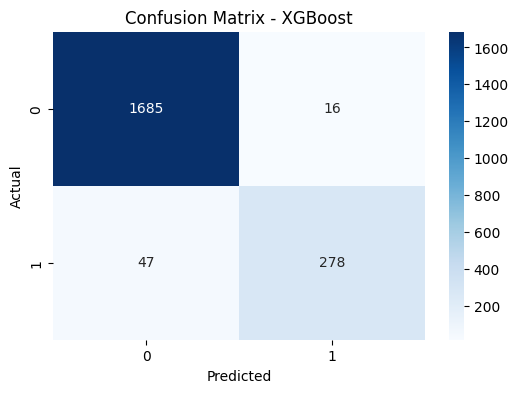

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()

ROC-AUC Score

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = xgb_model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9925093836204948


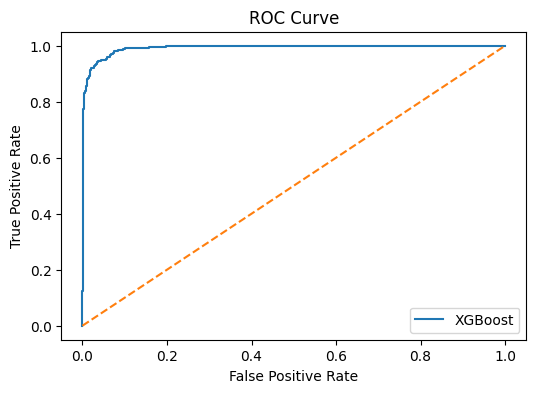

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()

In [ ]:
train_prob = xgb_model.predict_proba(X_train)[:,1]
test_prob = xgb_model.predict_proba(X_test)[:,1]

train_auc = roc_auc_score(y_train, train_prob)
test_auc = roc_auc_score(y_test, test_prob)

print("Train ROC-AUC:", train_auc)
print("Test ROC-AUC:", test_auc)

Train ROC-AUC: 0.999939902610599
Test ROC-AUC: 0.9925093836204948


Berdasarkan hasil evaluasi model menggunakan ROC-AUC, model XGBoost memperoleh nilai ROC-AUC sebesar 0.9999 pada data training dan 0.9925 pada data testing.

Nilai ROC-AUC yang sangat mendekati 1 menunjukkan bahwa model memiliki kemampuan yang sangat baik dalam membedakan pelanggan yang berpotensi churn dan pelanggan yang tetap menggunakan layanan.

Perbedaan nilai ROC-AUC antara data training dan data testing juga sangat kecil, sehingga menunjukkan bahwa model mampu melakukan generalisasi dengan baik terhadap data yang belum pernah dilihat sebelumnya dan tidak menunjukkan indikasi overfitting yang signifikan.

Nilai ROC-AUC yang tinggi menunjukkan bahwa model mampu memberikan peringkat risiko churn kepada pelanggan dengan sangat baik. Hal ini memungkinkan perusahaan untuk mengidentifikasi pelanggan dengan probabilitas churn tertinggi dan memprioritaskan mereka dalam program retensi. Sehingga perusahaan dapat mengalokasikan sumber daya secara lebih efektif dan dapat mengoptimalkan strategi berbasis data.

## Analisis Interpretabilitas Model

Feature Importance

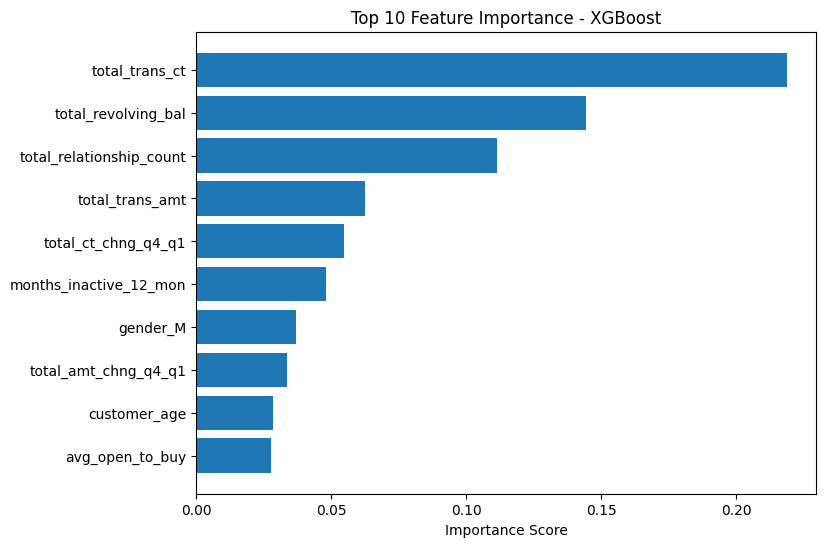

,Feature,Importance
12,total_trans_ct,0.218754
8,total_revolving_bal,0.144520
4,total_relationship_count,0.111272
11,total_trans_amt,0.062665
13,total_ct_chng_q4_q1,0.054879
5,months_inactive_12_mon,0.048235
15,gender_M,0.037107
10,total_amt_chng_q4_q1,0.033564
1,customer_age,0.028390
9,avg_open_to_buy,0.027760


In [ ]:
# mengambil feature importance dari model
importance = xgb_model.feature_importances_

# membuat dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# urutkan dari yang paling penting
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# tampilkan 10 fitur terpenting
top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.show()

feature_importance.head(10)

Interpretasi Fitur yang Penting

* total_trans_ct merupakan faktor paling berpengaruh. Pelanggan dengan jumlah transaksi yang rendah cenderung memiliki risiko churn yang lebih tinggi karena menunjukkan tingkat penggunaan layanan yang rendah.

* total_revolving_bal menunjukkan penggunaan saldo kredit pelanggan. Nilai yang rendah dapat mengindikasikan bahwa pelanggan mulai mengurangi penggunaan layanan bank.

* total_relationship_count merepresentasikan jumlah produk yang dimiliki pelanggan. Semakin sedikit produk yang dimiliki, semakin tinggi kemungkinan pelanggan untuk churn karena keterikatan terhadap bank lebih rendah.

* total_trans_amt menunjukkan total nilai transaksi pelanggan. Nilai transaksi yang rendah dapat menjadi indikasi rendahnya aktivitas penggunaan layanan.

Perbandingan dengan Hasil EDA

Hasil interpretasi model konsisten dengan temuan pada tahap EDA, di mana pelanggan dengan aktivitas transaksi yang rendah cenderung memiliki tingkat churn yang lebih tinggi. Hal ini menunjukkan bahwa model mampu menangkap pola yang relevan dengan kondisi bisnis.

Implikasi Bisnis

Berdasarkan faktor-faktor tersebut, perusahaan dapat menerapkan strategi retensi seperti:

- meningkatkan aktivitas transaksi melalui program promosi atau reward,

- menawarkan produk tambahan untuk meningkatkan keterikatan pelanggan,

- serta memonitor pelanggan dengan aktivitas transaksi yang menurun untuk melakukan intervensi lebih awal.

Strategi ini dapat membantu perusahaan mengurangi churn dan mempertahankan pelanggan yang sudah ada.

## Simulasi Dampak Bisnis

Identifikasi Customer Beresiko Churn

In [ ]:
# prediksi probabilitas churn
y_prob = xgb_model.predict_proba(X_test)[:,1]

# membuat dataframe hasil prediksi
results = X_test.copy()
results["actual_churn"] = y_test
results["churn_probability"] = y_prob

# threshold churn risk
threshold = 0.5

results["predicted_churn"] = (results["churn_probability"] >= threshold).astype(int)

results.head()

,user_id,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,...,income_category_$60K - $80K,income_category_$80K - $120K,income_category_Less than $40K,income_category_Unknown,card_category_Gold,card_category_Platinum,card_category_Silver,actual_churn,churn_probability,predicted_churn
2919,767114958,65,0,56,4,2,2,3226.0,2073,1153.0,...,False,False,True,False,False,False,False,0,0.001019,0
9301,708123033,41,3,30,2,1,1,11463.0,0,11463.0,...,False,False,True,False,False,False,True,0,0.000547,0
2936,715424283,31,0,21,5,2,2,1677.0,0,1677.0,...,False,False,True,False,False,False,False,0,0.116226,0
8134,717865008,51,1,36,2,1,1,1438.3,468,970.3,...,False,False,False,False,False,False,False,0,0.000095,0
5902,710188308,51,3,41,6,2,3,1519.0,1148,371.0,...,False,False,True,False,False,False,False,0,0.000377,0


In [ ]:
# Customer Beresiko Tinggi
high_risk_customers = results[results["churn_probability"] > 0.7]

print("Jumlah customer berisiko tinggi:", len(high_risk_customers))

Jumlah customer berisiko tinggi: 270


Asumsi Biaya Retensi

kita asumsikan biaya retensi itu $100 per customer

In [ ]:
retention_cost = 100  # biaya retensi per customer (dolar)

total_retention_cost = len(high_risk_customers) * retention_cost

print("Total biaya retensi:", total_retention_cost)

Total biaya retensi: 27000


Maka

Potensi Revenue yang Terselamatkan

In [ ]:
# estimasi revenue customer yang berisiko churn
potential_revenue_loss = high_risk_customers["total_trans_amt"].sum()

print("Potensi revenue yang berisiko hilang:", potential_revenue_loss)

Potensi revenue yang berisiko hilang: 873406


Simulasi Jika Model diterapkan

kita asumsikan model berhasil mempertahankan 30% customer churn

In [ ]:
retention_success_rate = 0.30

saved_revenue = potential_revenue_loss * retention_success_rate

print("Estimasi revenue yang dapat diselamatkan:", saved_revenue)

Estimasi revenue yang dapat diselamatkan: 262021.8


Menghitung Net Benefit

In [ ]:
net_benefit = saved_revenue - total_retention_cost

print("Net benefit jika menggunakan model:", net_benefit)

Net benefit jika menggunakan model: 235021.8


Perbandingan penerapan dan tanpa penerapan model

In [ ]:
scenario = pd.DataFrame({
    "Scenario": ["Tanpa Model", "Dengan Model"],
    "Revenue Diselamatkan": [0, saved_revenue],
    "Biaya Retensi": [0, total_retention_cost],
    "Net Benefit": [0, net_benefit]
})

scenario

,Scenario,Revenue Diselamatkan,Biaya Retensi,Net Benefit
0,Tanpa Model,0.0,0,0.0
1,Dengan Model,262021.8,27000,235021.8


Berdasarkan hasil simulasi dampak bisnis, penggunaan model churn prediction memberikan manfaat yang signifikan dibandingkan skenario tanpa model. Pada kondisi tanpa model, perusahaan tidak memiliki mekanisme untuk mengidentifikasi pelanggan yang berisiko churn sehingga tidak ada revenue yang dapat diselamatkan. Sebaliknya, dengan memanfaatkan model prediksi churn, perusahaan dapat menargetkan pelanggan berisiko tinggi untuk program retensi. Meskipun perusahaan perlu mengeluarkan biaya retensi sebesar 27.000, model ini memungkinkan perusahaan menyelamatkan potensi revenue sebesar 262.021,8 sehingga menghasilkan net benefit sebesar 235.021,8. Hal ini menunjukkan bahwa penggunaan model churn prediction dapat membantu perusahaan melakukan strategi retensi yang lebih efektif dan memberikan nilai bisnis yang positif.

## Executive Summary

Analisis ini bertujuan untuk mengidentifikasi pelanggan yang berisiko churn serta membantu bank menyusun strategi retensi berbasis data. Berdasarkan analisis data, ditemukan bahwa churn pelanggan merupakan permasalahan yang cukup signifikan karena dapat menyebabkan hilangnya potensi revenue dan meningkatkan biaya akuisisi pelanggan baru.

Hasil Exploratory Data Analysis (EDA) menunjukkan bahwa faktor utama yang berkaitan dengan churn adalah rendahnya aktivitas transaksi pelanggan, seperti jumlah transaksi yang sedikit, nilai transaksi yang rendah, serta tingkat keterikatan pelanggan terhadap produk bank yang terbatas. Hal ini menunjukkan bahwa tingkat engagement pelanggan terhadap layanan bank memiliki peran penting dalam mempertahankan loyalitas pelanggan.

Dalam tahap pemodelan, beberapa algoritma klasifikasi diuji dan dibandingkan menggunakan teknik validasi. Berdasarkan hasil evaluasi, model XGBoost dipilih sebagai model terbaik karena memiliki performa paling baik dalam mendeteksi pelanggan yang berisiko churn.

Simulasi dampak bisnis menunjukkan bahwa penggunaan model churn prediction memungkinkan perusahaan melakukan strategi retensi secara lebih terarah. Dengan asumsi biaya retensi tertentu, model ini tetap menghasilkan net benefit positif, karena potensi revenue yang dapat diselamatkan lebih besar dibandingkan biaya retensi yang dikeluarkan.

Oleh karena itu, perusahaan disarankan untuk memanfaatkan model ini sebagai sistem early warning untuk mengidentifikasi pelanggan berisiko churn dan menerapkan strategi retensi yang lebih proaktif guna mempertahankan pelanggan dan menjaga pendapatan perusahaan.